In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from model import *
import pandas as pd
from utils import *
import pickle as pkl
import os
from matplotlib.colors import LogNorm
import seaborn as sns
sns.set(style='whitegrid')
device = torch.device("cuda")

In [ ]:
def sample_batch_teacher(B, d_in, device="cuda"):
        W1, W2, W3 = teacher_weights
        x = torch.randn(B, d_in, device=device) / math.sqrt(d_in)
        h = torch.tanh(x @ W1) * 1.5927
        h = torch.tanh(h @ W2) * 1.5927
        y = h @ W3
        return x, y

def train_ntp_wntk(d_in, x_data, widths, B, T, lrs, sample_batch_fn, device="cuda"):
    train_losses = {w: {lr:[] for lr in lrs} for w in widths}
    ntk_diffs = {w: {lr:[] for lr in lrs} for w in widths}
    loss_fn = nn.MSELoss()
    for width in widths:
        for lr in lrs:
            has_nan = False
            model = MLP2NTP(d_in, width, 1).to(device)
            model.init_weights()
            optimizer = model.init_optimizer(lr)
            model.train()
            base_ntk = model.ntk_kernel(x_data)
            ntk_diffs[width][lr].append(base_ntk.cpu().numpy())
            for step in range(T):
                if has_nan:
                    train_losses[width][lr].append(np.nan)
                    continue
                x, y_true = sample_batch_fn(B, d_in, device=device)
                optimizer.zero_grad()
                y_pred = model(x)
                loss = loss_fn(y_pred, y_true)
                loss.backward()
                optimizer.step()
                train_losses[width][lr].append(loss.item())
                if torch.isnan(loss):
                    has_nan = True
                if step > 0 and (step < 1000 or step % 10 == 0):
                    ntk_diff = model.ntk_kernel(x_data) - base_ntk
                    ntk_diffs[width][lr].append(ntk_diff.cpu().numpy())
                if step % 2000 == 0 and step > 100:
                    print(f"Step {step} for width {width}, lr {lr}, Loss: {np.mean(train_losses[width][lr][-1000:])}")
            if has_nan:
                print(f"Model {width} with lr {lr} has NaN loss")
    return train_losses, ntk_diffs

In [5]:
d_in = 32
B = 512
teacher_weights = make_teacher(d_in, device, seed=42, teacher_width = 10000)
x_data = torch.randn(100, d_in, device=device) / math.sqrt(d_in)

In [9]:
widths = [512, 1024, 2048, 4096]
lrs = [0.5]
T = 20001
train_losses_ntp, ntk_diffs_ntp = train_ntp_wntk(d_in, x_data, widths, B, T, lrs, sample_batch_teacher, device)

Step 2000 for width 512, lr 0.5, Loss: 0.150319331638515
Step 4000 for width 512, lr 0.5, Loss: 0.13584084890037776
Step 6000 for width 512, lr 0.5, Loss: 0.1284062457755208
Step 8000 for width 512, lr 0.5, Loss: 0.12405063883960248
Step 10000 for width 512, lr 0.5, Loss: 0.12095654135942459
Step 12000 for width 512, lr 0.5, Loss: 0.11768861746788024
Step 14000 for width 512, lr 0.5, Loss: 0.11493871546536684
Step 16000 for width 512, lr 0.5, Loss: 0.11289684093743563
Step 18000 for width 512, lr 0.5, Loss: 0.11053456965833902
Step 20000 for width 512, lr 0.5, Loss: 0.10843767721205949
Step 2000 for width 1024, lr 0.5, Loss: 0.1535614644140005
Step 4000 for width 1024, lr 0.5, Loss: 0.13900097776204348
Step 6000 for width 1024, lr 0.5, Loss: 0.1298969871327281
Step 8000 for width 1024, lr 0.5, Loss: 0.12492358205467463
Step 10000 for width 1024, lr 0.5, Loss: 0.12053585033863783
Step 12000 for width 1024, lr 0.5, Loss: 0.11689496484398842
Step 14000 for width 1024, lr 0.5, Loss: 0.1136

In [15]:
steps_range= []
for step in range(20001):
    if step > 0 and (step < 1000 or step % 10 == 0):
        steps_range.append(step)

In [10]:
norms_ntk_diffs_ntp = []
for width in widths:
    norms_ntk_diffs_ntp.append(np.linalg.norm(np.array(ntk_diffs_ntp[width][0.5]), ord=2, axis=(-2, -1)))
    print(norms_ntk_diffs_ntp[-1].shape)

(2901,)
(2901,)
(2901,)
(2901,)


Text(0.5, 1.0, '||NTK(T) - NTK(0)||_{op} / ||NTK(0)||_{op}')

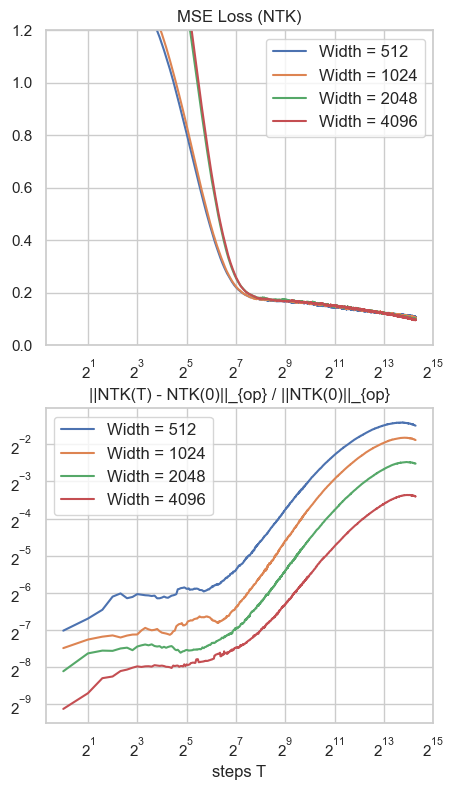

In [12]:
widths = [512, 1024, 2048, 4096]
axes, fig = plt.subplots(2,1, figsize=(5, 9))
ax = fig[0]
for i, width in enumerate(widths):
    losses = train_losses_ntp[width][0.5]
    lossesema = pd.Series(losses).ewm(halflife=25, adjust=False).mean().to_numpy()
    ax.plot(lossesema, label=f"Width = {width}")
ax.legend(fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_xscale("log", base=2)

ax.set_title("MSE Loss (NTK)")
ax = fig[1]
for i, width in enumerate(widths):
    ax.plot(steps_range, norms_ntk_diffs_ntp[i][1:] / norms_ntk_diffs_ntp[i][0], label=f"Width = {width}")
ax.legend(fontsize=12)
ax.set_xlabel("steps T")
ax.set_yscale("log", base=2)
ax.set_xscale("log", base=2)
ax.set_title("||NTK(T) - NTK(0)||_{op} / ||NTK(0)||_{op}")

In [14]:
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

0.427699712 GB allocated
0.845152256 GB reserved
